# Taylor Laboratuvarı — Özet Defter

Bu defter `02-python/src/` altındaki motoru kullanarak laboratuvarın ana
iddialarını hızlıca elden geçirir. Uzun taramalar ve tüm görseller ayrı
betiklerdedir; burası **oynamak** için.

Çalıştırmadan önce: `python -m pip install -r requirements.txt`

In [1]:
import sys, pathlib
KOK = pathlib.Path.cwd()
while not (KOK / '02-python').exists() and KOK != KOK.parent:
    KOK = KOK.parent
sys.path.insert(0, str(KOK / '02-python' / 'src'))

import numpy as np, sympy as sp
import ortam, taylor as T
ortam.grafik_temasi()
import matplotlib.pyplot as plt
print('proje kökü:', KOK)

proje kökü: <depo-koku>


## 1. Katsayı neden n!'e bölünür?

`n!` bir süsleme değil. `(x-a)^n` terimini n kez türevlediğinde önüne `n!`
düşer; `n!`'e bölmek tam olarak onu sıfırlar. Aşağıda `P_N`'in 0..N.
türevlerinin `f`'inkilerle **birebir** eşleştiğini görüyoruz.

In [2]:
expr, a, N = sp.sin(T.x), 0.0, 7
P = T.taylor_polinomu(expr, a, N)
print('P_7(x) =', sp.expand(P))
print()
for n in range(N + 1):
    solt = sp.diff(expr, T.x, n).subs(T.x, a)
    sagt = sp.diff(P, T.x, n).subs(T.x, a)
    print(f'n={n}:  f^(n)(a) = {solt}   P^(n)(a) = {sagt}   eşit mi: {sp.simplify(solt-sagt)==0}')

P_7(x) = -x**7/5040 + x**5/120 - x**3/6 + x

n=0:  f^(n)(a) = 0   P^(n)(a) = 0.0   eşit mi: True
n=1:  f^(n)(a) = 1   P^(n)(a) = 1   eşit mi: True
n=2:  f^(n)(a) = 0   P^(n)(a) = 0   eşit mi: True
n=3:  f^(n)(a) = -1   P^(n)(a) = -1   eşit mi: True
n=4:  f^(n)(a) = 0   P^(n)(a) = 0.0   eşit mi: True
n=5:  f^(n)(a) = 1   P^(n)(a) = 1   eşit mi: True
n=6:  f^(n)(a) = 0   P^(n)(a) = 0   eşit mi: True
n=7:  f^(n)(a) = -1   P^(n)(a) = -1   eşit mi: True


## 2. Lagrange kalanı bir EŞİTLİKTİR

`f(x) = P_N(x) + f^(N+1)(ξ)/(N+1)! · (x-a)^(N+1)`

Aşağıda ξ **aranıp bulunuyor**. Not: `ln(1+x)`, `x=1.8` noktası
yakınsaklık yarıçapının dışında — seri orada ıraksar, ama sonlu N için
eşitlik hâlâ geçerli.

In [3]:
from kalan_dogrulama import ksi_bul
for ad, e, a, N, xd in [('sin', sp.sin(T.x), 0.0, 5, 1.5),
                        ('exp', sp.exp(T.x), 0.0, 4, -1.2),
                        ('ln(1+x) [R dışı]', sp.log(1+T.x), 0.0, 6, 1.8)]:
    ksi = ksi_bul(e, a, N, xd)
    print(f'{ad:>18}  N={N}  x={xd:>5}   ξ = {ksi:.10f}   (a,x) içinde: {min(a,xd) < ksi < max(a,xd)}')

               sin  N=5  x=  1.5   ξ = 0.2092479405   (a,x) içinde: True
               exp  N=4  x= -1.2   ξ = -0.1866254762   (a,x) içinde: True
  ln(1+x) [R dışı]  N=6  x=  1.8   ξ = 0.1435686869   (a,x) içinde: True


## 3. float64 teoremi ihlal ettiriyor gibi görünür

Aşağıdaki noktada gerçek hata `~3e-41`. Çift duyarlıklı aritmetik onu
ölçemez; ölçtüğü şey kendi yuvarlama gürültüsüdür. Sınır "aşılmış"
görünür — 10^25 kat. mpmath ile 60 basamakta bakınca oran 1'in altına döner.

In [4]:
expr, a, N, xd = sp.exp(T.x), 1.0, 12, 0.996
f, P = T.sayisal_fonksiyon(expr), T.polinom_fonksiyonu(expr, a, N)
d_hata = float(abs(f(np.array([xd]))[0] - P(np.array([xd]))[0]))
sinir  = float(T.lagrange_sinir(expr, a, N, np.array([xd]))[0])
m_hata = T.yuksek_hassasiyet_sadece_hata(expr, a, N, xd)
print(f'Lagrange sınırı   : {sinir:.4e}')
print(f'float64 hata      : {d_hata:.4e}   oran = {d_hata/sinir:.3e}   <- sahte ihlal')
print(f'mpmath hata (60 b): {m_hata:.4e}   oran = {m_hata/sinir:.6f}   <- teorem sağlam')

Lagrange sınırı   : 2.9295e-41
float64 hata      : 4.4409e-16   oran = 1.516e+25   <- sahte ihlal
mpmath hata (60 b): 2.9287e-41   oran = 0.999714   <- teorem sağlam


## 4. Yakınsaklık yarıçapı kompleks düzlemde yaşar

`(1/N)·log|f-P_N|` büyüklüğü `log(|z-a|/R)`'ye yakınsar. İşareti
yakınsaklığı söyler, sıfır düzeyi `|z-a| = R` çemberidir. Aşağıda
`a`'yı değiştirip diskin **tekilliğe göre** yeniden şekillendiğini görün.

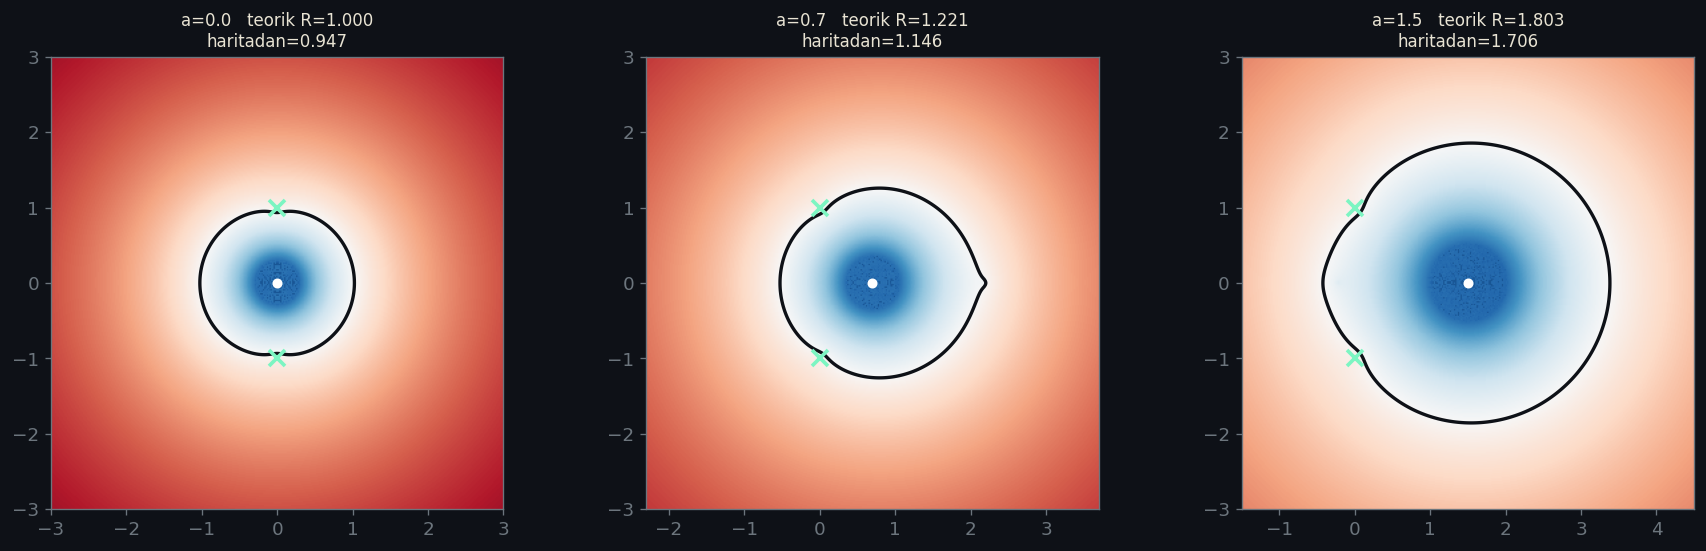

In [5]:
from kompleks_harita import hata_haritasi, yaricapi_haritadan_kestir

fig, eksenler = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, a in zip(eksenler, (0.0, 0.7, 1.5)):
    re, im, L = hata_haritasi(1/(1+T.x**2), a, 28, 3.0, 340)
    ax.imshow(L, extent=(re[0], re[-1], im[0], im[-1]), origin='lower',
              aspect='equal', cmap='RdBu_r', vmin=-0.75, vmax=0.75)
    ax.contour(re, im, L, levels=[0.0], colors=['#0E1117'], linewidths=2.0)
    for s in (1j, -1j):
        ax.plot(s.real, s.imag, 'x', color='#7CF5C2', ms=10, mew=2.2)
    ax.plot(a, 0, 'o', color='white', ms=5)
    R_teorik = abs(complex(a, 0) - 1j)
    ax.set_title(f'a={a}   teorik R={R_teorik:.3f}\nharitadan={yaricapi_haritadan_kestir(re,im,L,a):.3f}', fontsize=10)
    ax.grid(False)
plt.tight_layout(); plt.show()

## 5. Pürüzsüz ≠ analitik

`e^(-1/x²)` sonsuz kez türevlenebilir, tüm türevleri 0'da sıfır, dolayısıyla
Maclaurin serisi özdeş olarak sıfır. Ama fonksiyon sıfır değil.

In [6]:
fs = sp.exp(-1/T.x**2)
for n in range(6):
    print(f'f^({n})(0) =', sp.limit(sp.diff(fs, T.x, n), T.x, 0))
print()
print('Maclaurin serisi ≡ 0,  ama f(0.5) =', float(sp.N(fs.subs(T.x, 0.5))))

f^(0)(0) = 0
f^(1)(0) = 0
f^(2)(0) = 0
f^(3)(0) = 0
f^(4)(0) = 0


f^(5)(0) = 0

Maclaurin serisi ≡ 0,  ama f(0.5) = 0.01831563888873418


## 6. Sarkaç: atılan terim periyotta geri dönüyor

`sin θ ≈ θ` yaklaşımı `θ³/6`'yı atar. Faturası `T ≈ T₀(1 + θ₀²/16)`.

In [7]:
from sarkac import periyodu_olc, tam_periyot_eliptik, taylor_periyot, T0
print(f'harmonik T0 = {T0:.6f} s  (genlikten bağımsız)\n')
for d in (10, 45, 90, 150):
    th = np.deg2rad(d)
    o, e, t = periyodu_olc(th), tam_periyot_eliptik(th), taylor_periyot(th, 2)
    print(f'θ0={d:>4}°   ölçülen={o:.5f}   tam={e:.5f}   Taylor={t:.5f}   '
          f'harmoniğe göre sapma={100*(e/T0-1):6.2f}%')

harmonik T0 = 2.006409 s  (genlikten bağımsız)

θ0=  10°   ölçülen=2.01024   tam=2.01024   Taylor=2.01023   harmoniğe göre sapma=  0.19%
θ0=  45°   ölçülen=2.08661   tam=2.08661   Taylor=2.08376   harmoniğe göre sapma=  4.00%
θ0=  90°   ölçülen=2.36825   tam=2.36825   Taylor=2.31582   harmoniğe göre sapma= 18.03%
θ0= 150°   ölçülen=3.53570   tam=3.53570   Taylor=2.86589   harmoniğe göre sapma= 76.22%


---
Tüm görseller ve tam tablolar için:

```
python 02-python/src/kalan_dogrulama.py
python 02-python/src/kompleks_harita.py
python 02-python/src/yakinsaklik_orani.py
python 02-python/src/analitik_degil.py
python 02-python/src/sarkac.py
python 02-python/src/frobenius.py
```

Çıktılar: `out/gorseller/`, `out/tablolar/`